# Imports

In [1]:
import numpy as np
from manim import *
from scipy.spatial.transform import Rotation as R, Slerp
# graph implementation
import networkx as nx
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import numpy as np
from spacecraft_libraries import genetic_code, data_structures, new_opts, dynamics
import pygad
import multiprocessing as mp
import pandas as pd

# Main Classes

## Space Craft Agent Class

In [2]:

class SpaceAgent:
    def __init__(self, position, id, sys_params, bc):
        self.position = position
        self.id = id
        self.best_solution=None
        self.best_solution_fitness= -np.inf
        self.initial_population = None # initial population set for the ga
        self.population = None # population used for migration
        self.sys_params = sys_params
        self.ga_instance = None
        self.bc = bc
        self.best_tau = None
        self.elite_fits=None
        self.elite_pops=None
        self.migrants_recieved={}
        self.population_fitness = None
        self.neighbours={}
        self.final_individual=None
        self.final_soln_fitness = -np.inf
        self.final_traj=None
        self.final_Ctrl = None
        self.final_Q = None
        self.final_cost = -np.inf
        self.final_tau=None
        self.best_projected_traj=None
        self.best_projected_tau=None
        self.best_projected_fitness=None


    def island_GA_initiate(self, epsilon, pop_size):
        self.initial_population = genetic_code.pop_gen_new(self.bc, self.sys_params, self.sys_params.N, epsilon, pop_size)
        self.initial_population = [individual.flatten() for individual in self.initial_population]
        self.population = np.array(self.initial_population, copy=True)
        
        def callback_generation(ga_instance):
            #this function can be used to exit the 
            best_overall_fitness = ga_instance.best_solution()[1]
            # Print the best fitness values
            print(f"Generation {ga_instance.generations_completed}: Best Overall Fitness = {best_overall_fitness}")
            return None

        #fitness_wrapper = func_tools
        def fitness_wrapper(ga_instance, solution, solution_idx):
            return genetic_code.fitness_func(ga_instance,self.sys_params.N, epsilon, self.sys_params,self.bc, solution,solution_idx)
        

        self.ga_instance = pygad.GA(num_generations=1, num_parents_mating=int(pop_size/2), initial_population=self.initial_population, sol_per_pop=pop_size,  fitness_func=fitness_wrapper, num_genes=self.sys_params.N * 3, mutation_percent_genes=10,  crossover_type="two_points", mutation_type="random", mutation_by_replacement=False,parent_selection_type="sss",  keep_parents=-1, keep_elitism= int(pop_size/4),allow_duplicate_genes=True, on_generation=callback_generation)

        print("Initialisation from within the init function done")

    def step_one_generation(self):
        if self.ga_instance is None:
            raise RuntimeError("GA not initialised. call init_island_ga() first.")

        # ensure the GA uses current population for this step
        if self.population is not None:
            self.ga_instance.initial_population = np.array(self.population, copy=True)
        self.ga_instance.num_generations=1 #setting to two

        
        self.ga_instance.run() # running one generation

        # then copying the new population to further miugration
        self.population = np.array(self.ga_instance.population, copy=True)

        fit = None
        for attr in ("last_generation_fitness", "last_population_fitness", "population_fitness"):
            if hasattr(self.ga_instance, attr):
                fit = np.array(getattr(self.ga_instance, attr), copy=True)
                break
        print(f"Fit from inside the steup function :{fit}")
        self.population_fitness = fit  # may be None if pygad doesn't expose it

        self.best_solution, self.best_solution_fitness, _ = self.ga_instance.best_solution()

    def inject_migrants_replace_worst(self):
        if self.migrants_recieved is None or len(self.migrants_recieved) == 0:
            return
        if self.population is None:
            raise RuntimeError("population not initialised")

        migrant_list = list(self.migrants_recieved.values())  # list of 1d arrays
        migrants = np.vstack(migrant_list)                    # shape (m, num_genes)

        fits = np.asarray(self.population_fitness)

        m = migrants.shape[0]                                 # number of migrants
        worst_idx = np.argsort(fits)[:m]                      # indices of worst m

        # replace worst m with migrants
        self.population[worst_idx] = migrants

        # fitness is now stale
        self.population_fitness = None


    def project_soln(self, epsilon):

        solution, solution_fitness,_ = self.ga_instance.best_solution() # taking the best solution
        tau = solution.reshape((self.sys_params.N, 3)) #reshaping it

        print("Using Nonlinear Torque Projection")

        #projecting into viable space
        self.best_projected_tau = new_opts.tau_proj_nonlin_new(tau, self.sys_params.N, epsilon, self.sys_params, self.bc)[0]
        #getting the projected tau's cost and actual viable trajectory
        traj, ctrl_opt, Q_opt, cost = new_opts.opt_given_tau_ipopt_new(self.best_projected_tau,self.sys_params.N, epsilon,  self.sys_params,  self.bc, num_iter=3000) #iterations fraom 1000 -  3000
        print("Found Projected versions of the solution")
        self.best_projected_traj = traj # save the trajectory
        self.best_projected_fitness=1/cost # save the fitness as the 1/cost


## Graph Class

In [3]:

class GraphSpawner:
    def __init__(self, attach_vecs, num_agents, sys_params, bc, epsilon):
        print(attach_vecs[i,:] for i in range(num_agents))
        self.system_params = sys_params
        self.boundary_cond = bc
        self.agents=[SpaceAgent(attach_vecs[i,:], i, sys_params, bc) for i in range(num_agents)] #creating a space agent with unique id and giving it the initial position vector
        self.num_agents=num_agents
        self.positions = [agent.position for agent in self.agents]
        self.agent_graph =nx.Graph()
        for i in range(self.num_agents):
            self.agent_graph.add_node(i)
        self.distances = cdist(self.positions, self.positions)
        self.migration_iteration = 0
        self.num_mig_iterations = 10
        self.consensus_counter = 0
        self.best_individuals_per_gen={}
        self.adj_mat = nx.adjacency_matrix(self.agent_graph)
        self.line_of_sight_limit = 100 #same units as the input units for the agent positions
        self.epsilon=epsilon

    def see_agents(self):
        for agent in self.agents:
            print(f"position:{agent.position}")
            print(f"agent id: {agent.id}")

    def see_graph(self):
        print(f"graph nodes: {list(self.agent_graph.nodes)}")
        print(f"edges: {list(self.agent_graph.edges)}")
        fig = plt.figure()
        nx.draw(self.agent_graph, with_labels=True)

    def build_graph(self):

        print(f"Distances:{self.distances}")
        
        for current_pos in range(self.num_agents-1):
            print(f"Current id: {current_pos}")
            row_dist = self.distances[current_pos,:]
            ids = [i for i, dist in enumerate(row_dist) if (dist<self.line_of_sight_limit) and dist>0]
            self.agent_graph.add_edges_from((current_pos, n_id) for n_id in ids)
            print(f"ids: {ids}")


    def ts_rsg_graph_builder(self):
        print("In the RSG Builder")


    def communicator(self):
        print("exchanging individuals to all the nodes connected via line of sight")
        if self.best_individuals_per_gen != None:
            self.best_individuals_per_gen.clear() #clearing out the array in prep for latest data

        #collecting all the best individuals
        for node_id in self.agent_graph.nodes:
            agent = self.agents[node_id]
            if agent.best_solution is None:
                raise RuntimeError(f"agent {node_id} has no best_solution yet. call step_one_generation() before communicator.")
            self.best_individuals_per_gen[node_id] = np.array(agent.best_solution, copy=True)
            if agent.migrants_recieved != None:
                agent.migrants_recieved.clear() #clearing out the previous migrants to prep for current ones
            # this will now be used as reference to set up the recieving for all the agents
            
        for node_id in self.agent_graph.nodes:
            agent=self.agents[node_id]
            for neighbour_id in self.agent_graph.nodes: 
                if neighbour_id==node_id:
                    continue
                if self.agent_graph.has_edge(node_id, neighbour_id):
                    agent.migrants_recieved[neighbour_id] = np.array(self.best_individuals_per_gen[neighbour_id], copy=True)
            print("migrants received:", agent.migrants_recieved)

        print(f"Shuffling done")
        return True

    def migration(self, pop_size):
        print("Migration phase begins")

        #set up the adjacency matrix:
        self.adj_mat = nx.adjacency_matrix(self.agent_graph)

        #initialise the GA for all the islands
        for node_id in self.agent_graph.nodes:
            agent=self.agents[node_id]
            agent.island_GA_initiate(self.epsilon, pop_size) 
        
        print("initialisation done now. beginning the loop")

        for i in range(self.num_mig_iterations):
            print(f"Starting {i} Generation")
            for node_id in self.agent_graph.nodes:
                agent=self.agents[node_id]
                agent.step_one_generation()
            print("One generation Step complete")

            print("Propagating the best along the graph now")
            self.communicator()
            # call to the graph communication function

            print("Updating the Population")
            for node_id in self.agent_graph.nodes:
                agent=self.agents[node_id]
                agent.inject_migrants_replace_worst()
            #continue the loop
        
        print(f"Genetic Island Evolution done for {self.num_mig_iterations} iterations")
        return True

    def consensus_phase(self, max_iters=100):
        print("consensus phase now")
        G = self.agent_graph
        nodes = list(G.nodes())

        # one round of projection before forming the tuple
        for i in nodes:
            self.agents[i].project_soln(self.epsilon)
            print(f"Projection done for agent {i}")

        state = {i: (float(self.agents[i].best_projected_fitness), self.agents[i].best_projected_tau) for i in nodes} 
        print(f"The state of the sytem now is: {state}")
        counter = 0
        for k in range(max_iters):
            print(f"Consensus Iteration: {k}")
            print(f"The system state this iteration is: {state}")
            new = {i: max([state[i]] + [state[j] for j in G.neighbors(i)],key=lambda t: t[0] ) for i in nodes}
            print(f"The new state now is: {new}")
            if new == state:
                for i in nodes:
                    self.agents[i].final_soln_fitness = new[i][0]
                    self.agents[i].final_tau=new[i][1]
                break
            state = new
            counter+=1

        best_fitness, best_tau = next(iter(state.values()))
        print("best fitness:", best_fitness)
        print(f"best tau: {best_tau}")
        print("Best Individual reached")

        # going around and projecting again cuz why not
        for i in nodes:
            tau = self.agents[i].final_tau
            print(f"Projecting and Calculating optimum control for agent {i}")

            self.agents[i].final_traj, self.agents[i].final_Ctrl, self.agents[i].final_Q, self.agents[i].final_cost = new_opts.opt_given_tau_ipopt_new(tau, self.system_params.N, self.epsilon, self.system_params, self.boundary_cond, num_iter=3000)

            print(f"final trajectory for this agent: {self.agents[i].final_traj} ")
            print(f"Final control inputs for this agent: { self.agents[i].final_Ctrl}")
        
        print(f"Consensus finished with iterations : {counter}")
        return self.agents[0].final_traj, self.agents[0].final_Ctrl, self.agents[i].final_cost
    
    def constraint_checker(self):
        ga_X, _ = dynamics.forward_pass_dynamics( self.system_params, self.boundary_cond, self.agents[0].final_Ctrl) # this will be in the state vector form 
        #print(f"GA_X:{ga_X}")
        violation = 0
        violation+= np.linalg.norm(self.agents[0].final_traj.states[-1].r - self.boundary_cond.xf.r)
       # Quaternion indices (q1 to q4)
        violation += min(np.linalg.norm(self.agents[0].final_traj.states[-1].eps - self.boundary_cond.xf.eps), np.linalg.norm(self.agents[0].final_traj.states[-1].eps + self.boundary_cond.xf.eps)) # Angular velocity indices (omegas)
        violation += np.linalg.norm(self.agents[0].final_traj.states[-1].omega - self.boundary_cond.xf.omega)

        cost = np.sum(np.square(self.agents[0].final_Ctrl.U))

        print(f"violation is :{violation}")
        print(f"Cost is :{cost}")
        return violation, cost


## Animator

In [4]:

class TrajectoryWithThrustNotebookFastAllAgents(ThreeDScene):
    def __init__(self, fx,fu, run_time=10,  phi_deg=70, theta_deg=45,  zoom=0.35, pos_scale=1.0, mag_scale=1.0, star_mode="image",                star_image_path="stars.jpg",  n_stars=1000, star_radius=80, **kwargs):
        super().__init__(**kwargs)
        self.fx = fx
        self.fu = fu  # expected shape (6, 50, 3)
        self.run_time = run_time
        self.phi_deg = phi_deg
        self.theta_deg = theta_deg
        self.zoom = zoom
        self.pos_scale = pos_scale
        self.mag_scale = mag_scale

        self.star_mode = star_mode
        self.star_image_path = star_image_path
        self.n_stars = n_stars
        self.star_radius = star_radius

    def make_starfield(self):
        stars = VGroup()
        for _ in range(self.n_stars):
            v = np.random.normal(size=3)
            v = self.star_radius * v / np.linalg.norm(v)
            star = Dot3D(
                point=v,
                radius=0.03,
                color=WHITE,
                fill_opacity=np.random.uniform(0.4, 1.0),
            )
            stars.add(star)
        return stars

    def construct(self):
        fx = self.fx
        fu = self.fu

        # background
        self.camera.background_color = "#000010"
        if self.star_mode == "image":
            # simplest possible: flat image behind everything (2D overlay)
            bg = ImageMobject(self.star_image_path).set_opacity(1.0)
            bg.set_height(config.frame_height)
            bg.set_width(config.frame_width)
            bg.set_z_index(-1000)
            self.add_fixed_in_frame_mobjects(bg)
        else:
            # 3D star shell
            self.add(self.make_starfield())

        self.set_camera_orientation(phi=self.phi_deg * DEGREES, theta=self.theta_deg * DEGREES)
        self.camera.set_zoom(self.zoom)

        N = len(fx.states)          # 51
        steps = N - 1            # 50

        # build system (octahedron + 6 actuator cones)
        octahedron = Octahedron(edge_length=1)
        octahedron.graph[0].set_color(BLUE)
        octahedron.faces[2].set_color(DARK_BLUE)

        vertices = np.array(octahedron.vertex_coords)
        centre = octahedron.get_center()

        system = VGroup(octahedron)
        for v in vertices:
            d_local = normalize(v - centre)
            cone = Cone(
                base_radius=0.2,
                height=0.2,
                direction=-d_local,
                color=BLUE,
                fill_opacity=0.3,
            )
            cone.move_to(v + 0.1 * d_local)
            system.add(cone)

        system.move_to(ORIGIN)
        base_system = system.copy()
        self.add(system)

        # time in [0,1]
        s = ValueTracker(0.0)

        # quaternion slerp (expects (x, y, z, w))
        #rots = R.from_quat(fx.states[:].eps)
        quats = np.vstack([s.eps for s in fx.states])
        rots = R.from_quat(quats)
        slerp = Slerp(np.arange(N), rots)

        def interp_pose(alpha):
            tau = np.clip(alpha * (N - 1), 0, N - 1)
            k = int(np.floor(tau))
            u = tau - k

            if k >= N - 1:
                p = fx.states[N-1].r
            else:
                p = (1 - u) * fx.states[k].r + u * fx.states[k+1].r
            p = self.pos_scale * p

            r = slerp([tau])[0]
            return p, r


        start_pos, start_rot = interp_pose(0.0)
        start_ghost = base_system.copy()
        start_ghost.apply_matrix(start_rot.as_matrix())
        start_ghost.move_to(start_pos)
        start_ghost.set_color(RED)
        start_ghost.set_opacity(0.18)
        start_ghost.set_z_index(-10)
        self.add(start_ghost)

        # final ghost
        final_pos, final_rot = interp_pose(1.0)
        final_ghost = base_system.copy()
        final_ghost.apply_matrix(final_rot.as_matrix())
        final_ghost.move_to(final_pos)
        final_ghost.set_color(RED)
        final_ghost.set_opacity(0.25)
        final_ghost.set_z_index(-10)
        self.add(final_ghost)

        # rigid body updater: rotate from template then translate
        def body_updater(m):
            p, r = interp_pose(s.get_value())
            new = base_system.copy()
            new.apply_matrix(r.as_matrix())
            new.move_to(p)
            m.become(new)

        system.add_updater(body_updater)

        # thrust magnitude normalisation for proportional visuals
        mags = np.linalg.norm(fu.U, axis=2)  # (6, 50)
        mag_max = float(np.max(mags)) if float(np.max(mags)) > 0 else 1.0

        # exhaust dots
        puffs = VGroup(*[
            Dot3D(point=ORIGIN, radius=0.05).set_color(ORANGE).set_opacity(0.0)
            for _ in range(6)
        ])
        self.add(puffs)

        def puffs_updater(_, dt):
            alpha = s.get_value()

            tau_u = np.clip(alpha * steps, 0, steps - 1e-9)
            k = int(np.floor(tau_u))
            u = tau_u - k

            for i in range(6):
                puff = puffs[i]

                if k >= steps - 1:
                    thrust = fu.U[i, steps - 1]
                    uu = 0.0
                else:
                    thrust = (1 - u) * fu.U[i, k] + u * fu.U[i, k + 1]
                    uu = u

                mag = np.linalg.norm(thrust)
                if mag < 1e-8:
                    puff.set_opacity(0.0)
                    continue

                d = -thrust / mag
                cone = system[1 + i]

                intensity = np.tanh(self.mag_scale * (mag / mag_max))
                envelope = np.sin(np.pi * uu)

                opacity = (0.15 + 0.85 * intensity) * envelope
                radius = 0.03 + 0.10 * intensity

                origin = cone.get_center() - 0.15 * d
                pos = origin - (0.25 + 0.35 * intensity) * uu * d

                newp = Dot3D(point=pos, radius=radius).set_color(ORANGE)
                newp.set_opacity(opacity)
                puff.become(newp)

        puffs.add_updater(puffs_updater)

        self.play(s.animate.set_value(1.0), run_time=self.run_time, rate_func=linear)


# Main Functions

## Whole Runner

In [5]:
# print("Scenario 1")
# rs = [np.array([-1, -1, -1]), np.array([0, 1, 0]), np.array([0, -1, 0])]


# I_mat = 1000*np.diag([3,2,3])
# num_agents = len(rs)
# sys_p = data_structures.SystemParams(mu=3.98e14, a=7e6, e=0.1, nu= np.pi / 4, I=I_mat, m=100, rs=rs, N=100)

# x0=data_structures.StateVector(r =[0,0,0], v=[0,0,0], eps=[0,0,0,1], omega=[0,0,0])
# print(x0.eps)
# xf=data_structures.StateVector(r =[5,5,5], v=[0,0,0], eps=[0.5,0.5,0.5,0.5], omega=[0,0,0])
# print(xf.eps)
# bc = data_structures.BoundaryConditions(x0=x0, xf=xf, tf=50)

# epsilon = 1e-5
# pop_size = 5
# print("num_agents:", num_agents)

# master_graph = GraphSpawner(np.array(rs), num_agents, sys_p, bc, epsilon=epsilon)
# master_graph.see_agents()
# master_graph.build_graph()
# master_graph.see_graph()
# print("Setup Done")


Scenario 2
[0.707, 0, 0.707, 0]
[0, 0, 0, 1]
num_agents: 3
<generator object GraphSpawner.__init__.<locals>.<genexpr> at 0x000001C0D76C4040>
position:[0.5 1.  1.5]
agent id: 0
position:[0.  0.5 2. ]
agent id: 1
position:[-0.5  1.  -1.5]
agent id: 2
Distances:[[0.         0.8660254  3.16227766]
 [0.8660254  0.         3.57071421]
 [3.16227766 3.57071421 0.        ]]
Current id: 0
ids: [1, 2]
Current id: 1
ids: [0, 2]
graph nodes: [0, 1, 2]
edges: [(0, 1), (0, 2), (1, 2)]
Setup Done


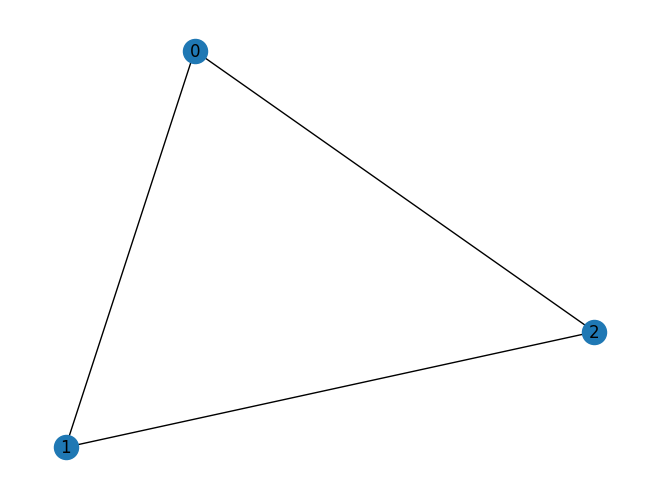

In [6]:
print("Scenario 2")
rs = [np.array([0.5,1,1.5]), np.array([0,0.5,2]), np.array([-0.5,1,-1.5])]

I_mat = 1000*np.diag([1,2,3])
num_agents = len(rs)
N = 40
sys_p = data_structures.SystemParams(mu=3.98e14, a=8e6, e=0.2, nu= np.pi / 4, I=I_mat, m=100, rs=rs, N=N)

x0=data_structures.StateVector(r =[1,10,-5], v=[0,0.5,0], eps=[0.707,0,0.707,0], omega=[0,0.1,0])
print(x0.eps)
xf=data_structures.StateVector(r =[0,0,0], v=[0,0,0], eps=[0,0,0,1], omega=[0,0,0])
print(xf.eps)
bc = data_structures.BoundaryConditions(x0=x0, xf=xf, tf=60)

epsilon = 1e-5
print("num_agents:", num_agents)

master_graph = GraphSpawner(np.array(rs), num_agents, sys_p, bc, epsilon=epsilon)
master_graph.see_agents()
master_graph.build_graph()
master_graph.see_graph()
print("Setup Done")


In [7]:
# print("Scenario 3")
# rs = [np.array([-1, -1.5, 0.5]), np.array([0.5, -1, -2.5]), np.array([-1, -1, 1.5]), np.array([1, 2.5, 0])]

# I_mat = 1000*np.diag([3,2,3])
# num_agents = len(rs)
# N = 250
# sys_p = data_structures.SystemParams(mu=3.98e14, a=1.05e7, e=0.01, nu= np.pi / 4, I=I_mat, m=100, rs=rs, N=N)

# x0=data_structures.StateVector(r =[-50,50,-50], v=[0,0,0], eps=[0,0,0,1], omega=[-0.01,0.01,0.01])
# print(x0.eps)
# xf=data_structures.StateVector(r =[5,-5,5], v=[0,0,0], eps=[0.5,-0.5,0.5,-0.5], omega=[0,0,0])
# print(xf.eps)
# bc = data_structures.BoundaryConditions(x0=x0, xf=xf, tf=500)

# epsilon = 1e-5
# #pop_size = 20
# print("num_agents:", num_agents)

# master_graph = GraphSpawner(np.array(rs), num_agents, sys_p, bc, epsilon=epsilon)
# master_graph.see_agents()
# master_graph.build_graph()
# master_graph.see_graph()
# print("Setup Done")

In [8]:
# code for the extended running 

gen_limits = [2]
iterations=1
     
generations_done = []
violation_data_dga=[]
cost_data_dga=[]
consen_cost=[]
final_trajectory=[]
pop_size = 5 #ensuring its same as CGA code
for k in range(len(gen_limits)):
    for i in range(iterations):
        limit = gen_limits[k]
        print(f"Iteration {i} for Generation Limit {limit}")
        master_graph.num_mig_iterations=limit
        master_graph.migration(pop_size=pop_size)
        print("Finished Migration")
        fx, fu, consensus_cost = master_graph.consensus_phase()
        print("Finished Consensus")
        #print(f"fu : {fu.U}")
        consen_cost.append(consensus_cost)
        violation, cost = master_graph.constraint_checker()
        violation_data_dga.append(violation)
        cost_data_dga.append(cost)
        generations_done.append(limit)
        final_trajectory.append(fx.states[:]) # saving for later plotting

print("Finished the Runs")
print("Violation Data: ")
print(violation_data_dga)
print("Cost Data :")
print(cost_data_dga)
print(f"Consensus cost: {consen_cost}")

df = pd.DataFrame({"violation_data" : violation_data_dga, "cost_data" : cost_data_dga, "consensus cost" : consen_cost, "generations_done" : generations_done})
df.to_csv("extended_test_run_2.csv", index=False) #* note to change this every run to ensure no file is overwritten
        

Iteration 0 for Generation Limit 2
Migration phase begins
Initialisation from within the init function done
Initialisation from within the init function done
Initialisation from within the init function done
initialisation done now. beginning the loop
Starting 0 Generation
Using Nonlinear Torque Projection
Current Cost: 6779.54498116175
Using Nonlinear Torque Projection
Current Cost: 10541.006947122221
Using Nonlinear Torque Projection
Current Cost: 6997.906125255803
Using Nonlinear Torque Projection
Current Cost: 6779.5601390941865
Using Nonlinear Torque Projection
Current Cost: 7710.387309419605
Using Nonlinear Torque Projection
Current Cost: 6289.257953152391
Using Nonlinear Torque Projection
Current Cost: 7047.41796461947
Using Nonlinear Torque Projection
Current Cost: 7109.399249423225
Using Nonlinear Torque Projection
Current Cost: 9469.696830333081
Using Nonlinear Torque Projection
Current Cost: 6289.257953152391
Using Nonlinear Torque Projection
Current Cost: 7047.41796461947
U

In [ ]:
#* PLOTTING CODE 

pos_data = np.array([st.r for st in final_trajectory[0]]) #extracting a section of the final trajectory
#in final trajectory, the 0 index is for the first iteration of the first generation limit from the previous cell. change as needed to view different runs
print(pos_data[:,0])
times = np.linspace(0, 50, 50)
x=pos_data[:50,0]
y=pos_data[:50,1]
z=pos_data[:50,2]

plt.plot(times, x, label='x')
plt.plot(times, y, label='y')
plt.plot(times, z, label='z')
plt.legend(loc="lower left")
plt.grid()

## Constraint Checker

In [ ]:
print("Now checking constraint")
violation = master_graph.constraint_checker()

print("Done! the code actually finished with no errors")

## Animator

Scenario 1
[0, 0, 0, 1]
[0.5, 0.5, 0.5, 0.5]
num_agents: 3
<generator object GraphSpawner.__init__.<locals>.<genexpr> at 0x00000152908524D0>
position:[-1 -1 -1]
agent id: 0
position:[0 1 0]
agent id: 1
position:[ 0 -1  0]
agent id: 2
Distances:[[0.         2.44948974 1.41421356]
 [2.44948974 0.         2.        ]
 [1.41421356 2.         0.        ]]
Current id: 0
ids: [1, 2]
Current id: 1
ids: [0, 2]
graph nodes: [0, 1, 2]
edges: [(0, 1), (0, 2), (1, 2)]
Setup Done


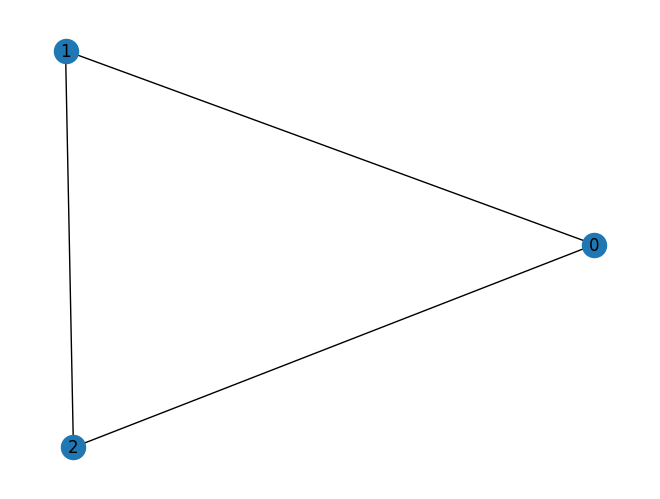

In [6]:
print("Scenario 1")
rs = [np.array([-1, -1, -1]), np.array([0, 1, 0]), np.array([0, -1, 0])]

#longer list for testing
I_mat = 1000*np.diag([3,2,3])
num_agents = len(rs)
sys_p = data_structures.SystemParams(mu=3.98e14, a=7e6, e=0.1, nu= np.pi / 4, I=I_mat, m=100, rs=rs, N=100)

x0=data_structures.StateVector(r =[0,0,0], v=[0,0,0], eps=[0,0,0,1], omega=[0,0,0])
print(x0.eps)
xf=data_structures.StateVector(r =[5,5,5], v=[0,0,0], eps=[0.5,0.5,0.5,0.5], omega=[0,0,0])
print(xf.eps)
bc = data_structures.BoundaryConditions(x0=x0, xf=xf, tf=50)

epsilon = 1e-5
pop_size = 5
print("num_agents:", num_agents)

master_graph = GraphSpawner(np.array(rs), num_agents, sys_p, bc, epsilon=epsilon)
master_graph.see_agents()
master_graph.build_graph()
master_graph.see_graph()
print("Setup Done")


In [ ]:
config.media_width = "75%"

with tempconfig({"quality": "high_quality",   "frame_rate": 20, "disable_caching": True,}):
    scene = TrajectoryWithThrustNotebookFastAllAgents(fx,fu,run_time=12, phi_deg=70, theta_deg=45,zoom=0.5,star_mode="image", star_image_path="stars.jpg")
    scene.render()

Video(scene.renderer.file_writer.movie_file_path)

In [ ]:
# mags = np.linalg.norm(fu.U, axis=2)
